In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [25]:
dataframe = pd.read_csv("BankNote_Authentication.csv")
dataframe

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


<Axes: >

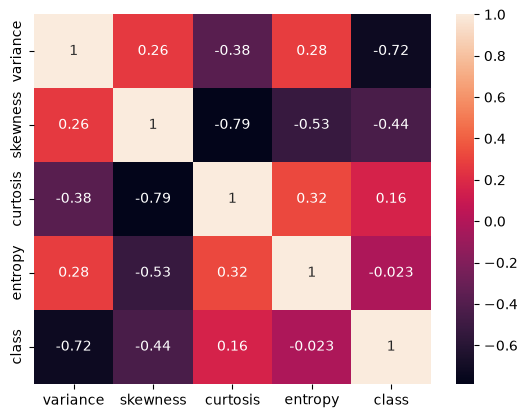

In [9]:
corr = dataframe.corr()
sns.heatmap(corr, annot=True)

In [10]:
feature = ["variance", "skewness", "curtosis", "entropy"]
X = dataframe[feature]
y = dataframe['class']

X,y

(      variance  skewness  curtosis  entropy
 0      3.62160   8.66610   -2.8073 -0.44699
 1      4.54590   8.16740   -2.4586 -1.46210
 2      3.86600  -2.63830    1.9242  0.10645
 3      3.45660   9.52280   -4.0112 -3.59440
 4      0.32924  -4.45520    4.5718 -0.98880
 ...        ...       ...       ...      ...
 1367   0.40614   1.34920   -1.4501 -0.55949
 1368  -1.38870  -4.87730    6.4774  0.34179
 1369  -3.75030 -13.45860   17.5932 -2.77710
 1370  -3.56370  -8.38270   12.3930 -1.28230
 1371  -2.54190  -0.65804    2.6842  1.19520
 
 [1372 rows x 4 columns],
 0       0
 1       0
 2       0
 3       0
 4       0
        ..
 1367    1
 1368    1
 1369    1
 1370    1
 1371    1
 Name: class, Length: 1372, dtype: int64)

In [19]:
model = GradientBoostingClassifier()

x_train,x_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
x_train, y_train

(      variance  skewness  curtosis   entropy
 1282   -1.9983   -6.6072   4.82540 -0.419840
 535     1.9476   -4.7738   8.52700 -1.866800
 890    -1.6637    3.2881  -2.27010 -2.222400
 1368   -1.3887   -4.8773   6.47740  0.341790
 371     4.1529   -3.9358   2.86330 -0.017686
 ...        ...       ...       ...       ...
 1095    1.1640    3.9130  -4.55440 -3.867200
 1130   -2.2918   -7.2570   7.95970  0.921100
 1294   -7.0364    9.2931   0.16594 -4.539600
 860    -3.4605    2.6901   0.16165 -1.022400
 1126   -3.3582   -7.2404  11.44190 -0.571130
 
 [1029 rows x 4 columns],
 1282    1
 535     0
 890     1
 1368    1
 371     0
        ..
 1095    1
 1130    1
 1294    1
 860     1
 1126    1
 Name: class, Length: 1029, dtype: int64)

In [20]:
model.fit(x_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [23]:
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_pred=y_pred, y_true= y_test)
r2_score = r2_score(y_pred=y_pred, y_true=y_test)

In [24]:
accuracy, r2_score

(0.9970845481049563, 0.9881854505373381)